In [5]:
import numpy as np
import pandas as pd
import cv2
import os
import random
import threading


%matplotlib inline
import matplotlib.pyplot as plt

In [6]:
from urllib.request import urlopen
def getData(url,dirname="data",img_shape=(100,100)):
    data = pd.read_csv(url,sep="\t",skiprows=2,header=None,names=['Name','imagenum','url','rect','md5'])
    print(data.shape)
    totalrows=data.shape[0]
    total_personalities = data.Name.nunique()
    current = 0
    if not os.path.exists(dirname): os.mkdir(dirname)
    j=0
    for i in range(data.shape[0]):
        if not os.path.exists(os.path.join(dirname,data.iloc[i].Name)):
            os.mkdir(os.path.join(dirname,data.iloc[i].Name))
            current+=1
            print("{} : {}/{} {:.2f}% done".format(dirname,current,total_personalities,i*100/totalrows))
            j=0
        try:
            resp = urlopen(data.iloc[i].url,timeout=1)
            image = np.asarray(bytearray(resp.read()), dtype="uint8")
            image = cv2.imdecode(image, cv2.COLOR_BGR2GRAY)
            p1,p2,p3,p4 = tuple(map(int,data.iloc[i].rect.split(',')))
            image = image[p2:p4,p1:p3]
            image = cv2.resize(image,img_shape,interpolation = cv2.INTER_AREA)
            plt.imsave(os.path.join(dirname,data.iloc[i].Name,str(j)+'.jpg'),image)
            j+=1
        except:
            pass

In [7]:
# data_e = threading.Thread(target = getData, 
#                            args = ('http://www.cs.columbia.edu/CAVE/databases/pubfig/download/dev_urls.txt', 'eval'))
# data_e.start()

In [8]:
# data_d = threading.Thread(target = getData, 
#                            args = ('http://www.cs.columbia.edu/CAVE/databases/pubfig/download/eval_urls.txt', 'train'))
# data_d.start()

In [9]:
# date_d.join()
# data_e.join()

In [10]:
root = "train"
img_shape = (100,100)
for path, subdirs, files in os.walk(root):
    for name in files:
        img_path = os.path.join(path, name)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        image = cv2.resize(image,img_shape,interpolation = cv2.INTER_AREA)
        cv2.imwrite(img_path, image)

In [11]:
def getMiniBatch(batch_size=32,prob=0.5,path = "train"):
    persons = os.listdir(path)
    left = [];right = []
    target = []
    for _ in range(batch_size):
        res = np.random.choice([0,1],p=[1-prob,prob])
        if res==0:
            p1,p2 = tuple(np.random.choice(persons,size=2,replace=False))
            while len(os.listdir(os.path.join(path,p1)))<1 or len(os.listdir(os.path.join(path,p2)))<1:
                p1,p2 = tuple(np.random.choice(persons,size=2,replace=False))
            p1 = os.path.join(path,p1,random.choice(os.listdir(os.path.join(path,p1))))
            p2 = os.path.join(path,p2,random.choice(os.listdir(os.path.join(path,p2))))
            p1,p2 = np.expand_dims(cv2.imread(p1,0),-1),np.expand_dims(cv2.imread(p2,0),-1)
            left.append(p1);right.append(p2)
            target.append(0)
        else:
            p = np.random.choice(persons)
            while len(os.listdir(os.path.join(path,p)))<2:
                p = np.random.choice(persons)
            p1,p2 = tuple(np.random.choice( os.listdir(os.path.join(path,p)), size=2, replace=False ))
            p1,p2 = os.path.join(path,p,p1),os.path.join(path,p,p2)
            p1,p2 = np.expand_dims(cv2.imread(p1,0),-1),np.expand_dims(cv2.imread(p2,0),-1)
            left.append(p1);right.append(p2)
            target.append(1)
    return [np.array(left),np.array(right)],np.array(target)

In [12]:
def test_oneshot(model,N,verbose=0):
    """Test average N way oneshot learning accuracy of a siamese neural net over k one-shot tasks"""
    if verbose:
        pass
        #print("Evaluating model on {} one-shot learning tasks ...".format(N))
    inputs, targets = getMiniBatch(N,path="eval")
    probs = model.predict(inputs)
    output = (np.squeeze(probs)>0.5)*1
    percent_correct = (output==targets).sum()*100/N
    if verbose:
        print("Got an average of {}% {} way one-shot learning accuracy".format(percent_correct,N))
    return percent_correct

In [26]:
from keras.layers import Input, Conv2D, Dense, Flatten,MaxPooling2D
from keras.layers import Lambda, Subtract
from keras.models import Model, Sequential
from keras.regularizers import l2
from keras import backend as K
from keras.optimizers import SGD,Adam
from keras.losses import binary_crossentropy

import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.utils import shuffle


def W_init(shape,name=None):
    values = np.random.normal(loc=0,scale=1e-2,size=shape)
    return K.variable(values,name=name)

def b_init(shape,name=None):
    values = np.random.normal(loc=0.5,scale=1e-2,size=shape)
    return K.variable(values,name=name)

input_shape = (100, 100, 1)
left_input = Input(input_shape)
right_input = Input(input_shape)

#build convnet to use in each siamese 'leg'
convnet = Sequential()
convnet.add(Conv2D(64,(10,10),activation='relu',input_shape=input_shape,kernel_regularizer=l2(2e-4)))
convnet.add(MaxPooling2D())
convnet.add(Conv2D(128,(7,7),activation='relu',
                   kernel_regularizer=l2(2e-4)))
convnet.add(MaxPooling2D())
convnet.add(Conv2D(128,(4,4),activation='relu',kernel_regularizer=l2(2e-4)))
convnet.add(MaxPooling2D())
convnet.add(Conv2D(256,(4,4),activation='relu',kernel_regularizer=l2(2e-4)))
convnet.add(Flatten())
convnet.add(Dense(4096,activation="sigmoid",kernel_regularizer=l2(1e-3)))

#encode each of the two inputs into a vector with the convnet
encoded_l = convnet(left_input)
encoded_r = convnet(right_input)

#merge two encoded inputs with the l1 distance between them
subtracted = Subtract()( [encoded_l,encoded_r]  )
both = Lambda(lambda x: abs(x))(subtracted)
prediction = Dense(1,activation='sigmoid')(both)
siamese_net = Model(inputs=[left_input,right_input],outputs=prediction)

# optimizer = SGD(0.0004,momentum=0.6,nesterov=True,decay=0.0003)

optimizer = Adam(0.0001)
#//TODO: get layerwise learning rates and momentum annealing scheme described in paperworking
siamese_net.compile(loss="binary_crossentropy",optimizer=optimizer)

siamese_net.count_params()

27417409

In [27]:
siamese_net.summary()

Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_11 (InputLayer)          [(None, 100, 100, 1  0           []                               
                                )]                                                                
                                                                                                  
 input_12 (InputLayer)          [(None, 100, 100, 1  0           []                               
                                )]                                                                
                                                                                                  
 sequential_5 (Sequential)      (None, 4096)         27413312    ['input_11[0][0]',               
                                                                  'input_12[0][0]']         

In [29]:
evaluate_every = 5000
loss_every = 500
batch_size = 32
N = 1000
best = 0
loss_history = []
for i in range(0,50000,1):
    print(i)
    (inputs,targets)= getMiniBatch(batch_size,path="train")
    loss=siamese_net.train_on_batch(inputs,targets)
    loss_history.append(loss)
    if i % loss_every == 0:
        vloss = siamese_net.test_on_batch(*getMiniBatch(batch_size,path="eval"))
        print("iteration {}, training loss: {:.7f}, validation loss : {:.7f}".format(i,np.mean(loss_history),vloss))
        loss_history.clear()
        val_acc = test_oneshot(siamese_net,N,verbose=True)
        print(val_acc)
        if val_acc >= best:
            print("saving")
            siamese_net.save('saved_best')
            best=val_acc

0
iteration 0, training loss: 5.2744198, validation loss : 5.2403173
32/32 [==============================] - 7s 208ms/step
Got an average of 50.9% 1000 way one-shot learning accuracy
50.9
saving


INFO:tensorflow:Assets written to: saved_best\assets


INFO:tensorflow:Assets written to: saved_best\assets


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


INFO:tensorflow:Assets written to: saved_best\assets


...

4001
4002
4003
4004
4005
4006
4007
4008
4009
4010
4011
4012
4013
4014
4015
4016
4017
4018
4019
4020
4021
4022
4023
4024
4025
4026
4027
4028
4029
4030
4031
4032
4033
4034
4035
4036
4037
4038
4039
4040
4041
4042
4043
4044
4045
4046
4047
4048
4049
4050
4051
4052
4053
4054
4055
4056
4057
4058
4059
4060
4061
4062
4063
4064
4065
4066
4067
4068
4069
4070
4071
4072
4073
4074
4075
4076
4077
4078
4079
4080
4081
4082
4083
4084
4085
4086
4087
4088
4089
4090
4091
4092
4093
4094
4095
4096
4097
4098
4099
4100
4101
4102
4103
4104
4105
4106
4107
4108
4109
4110
4111
4112
4113
4114
4115
4116
4117
4118
4119
4120
4121
4122
4123
4124
4125
4126
4127
4128
4129
4130
4131
4132
4133
4134
4135
4136
4137
4138
4139
4140
4141
4142
4143
4144
4145
4146
4147
4148
4149
4150
4151
4152
4153
4154
4155
4156
4157
4158
4159
4160
4161
4162
4163
4164
4165
4166
4167
4168
4169
4170
4171
4172
4173
4174
4175
4176
4177
4178
4179
4180
4181
4182
4183
4184
4185
4186
4187
4188
4189
4190
4191
4192
4193
4194
4195
4196
4197
4198
4199
4200


5526
5527
5528
5529
5530
5531
5532
5533
5534
5535
5536
5537
5538
5539
5540
5541
5542
5543
5544
5545
5546
5547
5548
5549
5550
5551
5552
5553
5554
5555
5556
5557
5558
5559
5560
5561
5562
5563
5564
5565
5566
5567
5568
5569
5570
5571
5572
5573
5574
5575
5576
5577
5578
5579
5580
5581
5582
5583
5584
5585
5586
5587
5588
5589
5590
5591
5592
5593
5594
5595
5596
5597
5598
5599
5600
5601
5602
5603
5604
5605
5606
5607
5608
5609
5610
5611
5612
5613
5614
5615
5616
5617
5618
5619
5620
5621
5622
5623
5624
5625
5626
5627
5628
5629
5630
5631
5632
5633
5634
5635
5636
5637
5638
5639
5640
5641
5642
5643
5644
5645
5646
5647
5648
5649
5650
5651
5652
5653
5654
5655
5656
5657
5658
5659
5660
5661
5662
5663
5664
5665
5666
5667
5668
5669
5670
5671
5672
5673
5674
5675
5676
5677
5678
5679
5680
5681
5682
5683
5684
5685
5686
5687
5688
5689
5690
5691
5692
5693
5694
5695
5696
5697
5698
5699
5700
5701
5702
5703
5704
5705
5706
5707
5708
5709
5710
5711
5712
5713
5714
5715
5716
5717
5718
5719
5720
5721
5722
5723
5724
5725


7051
7052
7053
7054
7055
7056
7057
7058
7059
7060
7061
7062
7063
7064
7065
7066
7067
7068
7069
7070
7071
7072
7073
7074
7075
7076
7077
7078
7079
7080
7081
7082
7083
7084
7085
7086
7087
7088
7089
7090
7091
7092
7093
7094
7095
7096
7097
7098
7099
7100
7101
7102
7103
7104
7105
7106
7107
7108
7109
7110
7111
7112
7113
7114
7115
7116
7117
7118
7119
7120
7121
7122
7123
7124
7125
7126
7127
7128
7129
7130
7131
7132
7133
7134
7135
7136
7137
7138
7139
7140
7141
7142
7143
7144
7145
7146
7147
7148
7149
7150
7151
7152
7153
7154
7155
7156
7157
7158
7159
7160
7161
7162
7163
7164
7165
7166
7167
7168
7169
7170
7171
7172
7173
7174
7175
7176
7177
7178
7179
7180
7181
7182
7183
7184
7185
7186
7187
7188
7189
7190
7191
7192
7193
7194
7195
7196
7197
7198
7199
7200
7201
7202
7203
7204
7205
7206
7207
7208
7209
7210
7211
7212
7213
7214
7215
7216
7217
7218
7219
7220
7221
7222
7223
7224
7225
7226
7227
7228
7229
7230
7231
7232
7233
7234
7235
7236
7237
7238
7239
7240
7241
7242
7243
7244
7245
7246
7247
7248
7249
7250


8576
8577
8578
8579
8580
8581
8582
8583
8584
8585
8586
8587
8588
8589
8590
8591
8592
8593
8594
8595
8596
8597
8598
8599
8600
8601
8602
8603
8604
8605
8606
8607
8608
8609
8610
8611
8612
8613
8614
8615
8616
8617
8618
8619
8620
8621
8622
8623
8624
8625
8626
8627
8628
8629
8630
8631
8632
8633
8634
8635
8636
8637
8638
8639
8640
8641
8642
8643
8644
8645
8646
8647
8648
8649
8650
8651
8652
8653
8654
8655
8656
8657
8658
8659
8660
8661
8662
8663
8664
8665
8666
8667
8668
8669
8670
8671
8672
8673
8674
8675
8676
8677
8678
8679
8680
8681
8682
8683
8684
8685
8686
8687
8688
8689
8690
8691
8692
8693
8694
8695
8696
8697
8698
8699
8700
8701
8702
8703
8704
8705
8706
8707
8708
8709
8710
8711
8712
8713
8714
8715
8716
8717
8718
8719
8720
8721
8722
8723
8724
8725
8726
8727
8728
8729
8730
8731
8732
8733
8734
8735
8736
8737
8738
8739
8740
8741
8742
8743
8744
8745
8746
8747
8748
8749
8750
8751
8752
8753
8754
8755
8756
8757
8758
8759
8760
8761
8762
8763
8764
8765
8766
8767
8768
8769
8770
8771
8772
8773
8774
8775


KeyboardInterrupt: 

In [30]:
siamese_net.save("saved_best.h5")

In [31]:
from tensorflow import keras
model = keras.models.load_model("saved_best.h5")

In [14]:
val_acc = None
while val_acc==None: 
    try:
        siamese_net = keras.models.load_model("saved_best.h5")
        val_acc = test_oneshot(siamese_net,1000,verbose=True)
        print("Accuracy: {}".format(val_acc))
    except:
        pass

32/32 [==============================] - 8s 236ms/step
Got an average of 47.9% 1000 way one-shot learning accuracy
Accuracy: 47.9


Total Faces Detected: 7


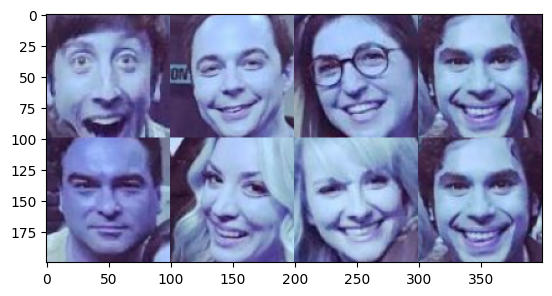

In [31]:
#haarcascade_frontalface_default.xml is saved model for face detection
faceCascade = cv2.CascadeClassifier("haarcascade_frontalface_default.xml")
def giveAllFaces(image,BGR_input=True,BGR_output=False):
    """
      return GRAY cropped_face,x,y,w,h 
    """
    gray = image.copy()
    if BGR_input:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    faces = faceCascade.detectMultiScale(
        gray,
        scaleFactor=1.3,
        minNeighbors=3,
        minSize=(30, 30)
    )
    if BGR_output:
        for (x, y, w, h) in faces:
            yield image[y:y+h,x:x+w,:],x,y,w,h
    else:
        for (x, y, w, h) in faces:
            yield gray[y:y+h,x:x+w],x,y,w,h

#to draw rectangle
#for (_,x, y, w, h) in giveAllFaces(image):
#    cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)

import math
def test(path="sample/tbbt.jpg"):
    image = cv2.imread(path)
    faces= [ cv2.resize(face,(100,100),interpolation = cv2.INTER_AREA) for face,_,_,_,_ in giveAllFaces(image,BGR_output=True)]
    print("Total Faces Detected: {}".format(len(faces)))
    t = math.ceil(len(faces)/2)
    i,one = 0,[]
    while i<t:
        one.append(faces[i]);i+=1
    two = one.copy()
    while i<len(faces):
        two[i-t] = faces[i];i+=1
    plt.imshow(np.vstack([np.hstack(one),np.hstack(two)]))

test() #other options - got.jpg, friends.jpg

In [32]:
def putBoxText(image,x,y,w,h,text="unknown"):
    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(image,text, (x,y-6), font, 1, (0, 255, 0), 2, cv2.LINE_AA)

In [42]:
def putCharacters(image,db="database"):
    dbs = os.listdir(db)
    right = np.array([ np.expand_dims(cv2.imread(os.path.join(db,x),0),-1) for x in dbs ])
    names = [ os.path.splitext(x)[0] for x in dbs ]
    for face,x,y,w,h in giveAllFaces(image):
        face = cv2.resize(face,(100,100),interpolation = cv2.INTER_AREA)
        face = np.expand_dims(face,-1)
        left = np.array([face for _ in range(len(dbs))])
        probs = np.squeeze(siamese_net.predict([left,right]))
        index = np.argmax(probs)
        prob = probs[index]
        name = "Unknown"
        if prob>=0.5:
            name = names[index]
            print(name, prob)
        putBoxText(image,x,y,w,h,text=name+"({:.2f})".format(prob))

1/1 [==============================] - 0s 45ms/step
Polas 0.9775598


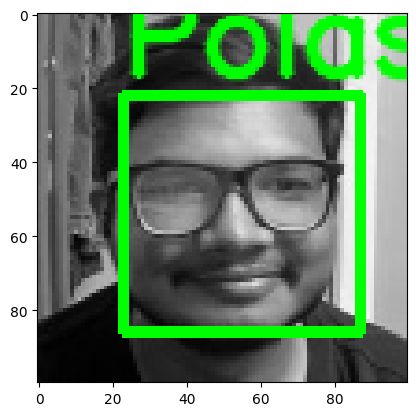

In [43]:
im = cv2.imread('test2.jpg',1)
putCharacters(im)
plt.imshow(im)